In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Entropy vs Gini: Comparing Decision Tree Splits on Breast Cancer Data

### Context & Goal

You work as a data scientist evaluating diagnostic models for tumour classification.
Your team is debating which **split criterion**—**Gini** or **Entropy**—is more effective for decision trees in medical data.
You will build two models using the **Wisconsin Breast Cancer Dataset**, compare their performance, and interpret the difference in how each criterion partitions information.

### Learning Targets

* Train two `DecisionTreeClassifier` models using different impurity criteria (`gini` vs `entropy`).
* Compare their accuracy and interpret any performance differences.
* Understand conceptually what *information gain* and *Gini impurity* measure.
* Evaluate the implications of using one criterion over the other.

### Dataset

**Name:** Wisconsin Breast Cancer Dataset <br>
**Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29) <br>
**Description:** 569 samples with 30 features describing the characteristics of cell nuclei (mean radius, texture, smoothness, etc.). <br>
**Target Variable:** `diagnosis` (`M` = malignant, `B` = benign) <br>
**Why this dataset:** Balanced, well-known binary classification benchmark—perfect for testing model interpretability and decision criteria.

### Task Instructions

1. **Data Preparation**

   * Load the dataset from `sklearn.datasets.load_breast_cancer`.
   * Convert it to a `DataFrame` with named columns.
   * Encode the target (`M` = 1, `B` = 0).
   * Split into training and test sets (80/20 split, `random_state=42`).

In [8]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

In [9]:
y = y["Diagnosis"].map({"M": 1, "B": 0})

In [10]:
# metadata
meta = breast_cancer_wisconsin_diagnostic.metadata

meta_df = pd.DataFrame(
	[(k, v) for k, v in meta.items() if v is not None], columns=["Attribute", "Value"]
)
display(meta_df)

,Attribute,Value
0,uci_id,17
1,name,Breast Cancer Wisconsin (Diagnostic)
2,repository_url,https://archive.ics.uci.edu/dataset/17/breast+...
3,data_url,https://archive.ics.uci.edu/static/public/17/d...
4,abstract,Diagnostic Wisconsin Breast Cancer Database.
5,area,Health and Medicine
6,tasks,[Classification]
7,characteristics,[Multivariate]
8,num_instances,569
9,num_features,30


2. **Train Two Decision Trees**

   * Model 1: instantiate `DecisionTreeClassifier(criterion='gini', max_depth=8, random_state=42)`.
   * Model 2: instantiate `DecisionTreeClassifier(criterion='entropy', max_depth=8, random_state=42)`.
   * Fit both models on the training data.


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
	X, y, stratify=y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.tree import DecisionTreeClassifier

dtc_1 = DecisionTreeClassifier(criterion="gini", max_depth=8, random_state=42)
dtc_2 = DecisionTreeClassifier(criterion="entropy", max_depth=8, random_state=42)

dtc_1.fit(X_train, y_train)
dtc_2.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


3. **Evaluate and Compare**

   * Predict test labels for both models.
   * Compute accuracy using `accuracy_score`.
   * Print the results side by side.


In [13]:
from sklearn.metrics import accuracy_score, classification_report

In [14]:
y_pred_1 = dtc_1.predict(X_test)
print(accuracy_score(y_test, y_pred_1))
print(classification_report(y_test, y_pred_1))

0.9298245614035088
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [15]:
y_pred_2 = dtc_2.predict(X_test)
print(accuracy_score(y_test, y_pred_2))
print(classification_report(y_test, y_pred_2))


0.956140350877193
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



4. **Interpretation**

   * Briefly discuss:

     * Whether both criteria yield similar accuracy.
     * Which criterion produces a simpler or more interpretable tree (compare number of leaves using `.get_n_leaves()`).
     * Theoretical difference:

       * *Gini Impurity:* measures how often a random sample would be incorrectly labelled.
       * *Entropy:* measures information content and uncertainty (log-based).

5. **(Optional)** Visualise the trees with `plot_tree` or `graphviz` and examine whether their splitting structures differ significantly.

In [16]:
print(f"Number of leaves for Gini: {dtc_1.get_n_leaves()}")
print(f"Number of leaves for Entropy: {dtc_2.get_n_leaves()}")

Number of leaves for Gini: 24
Number of leaves for Entropy: 17


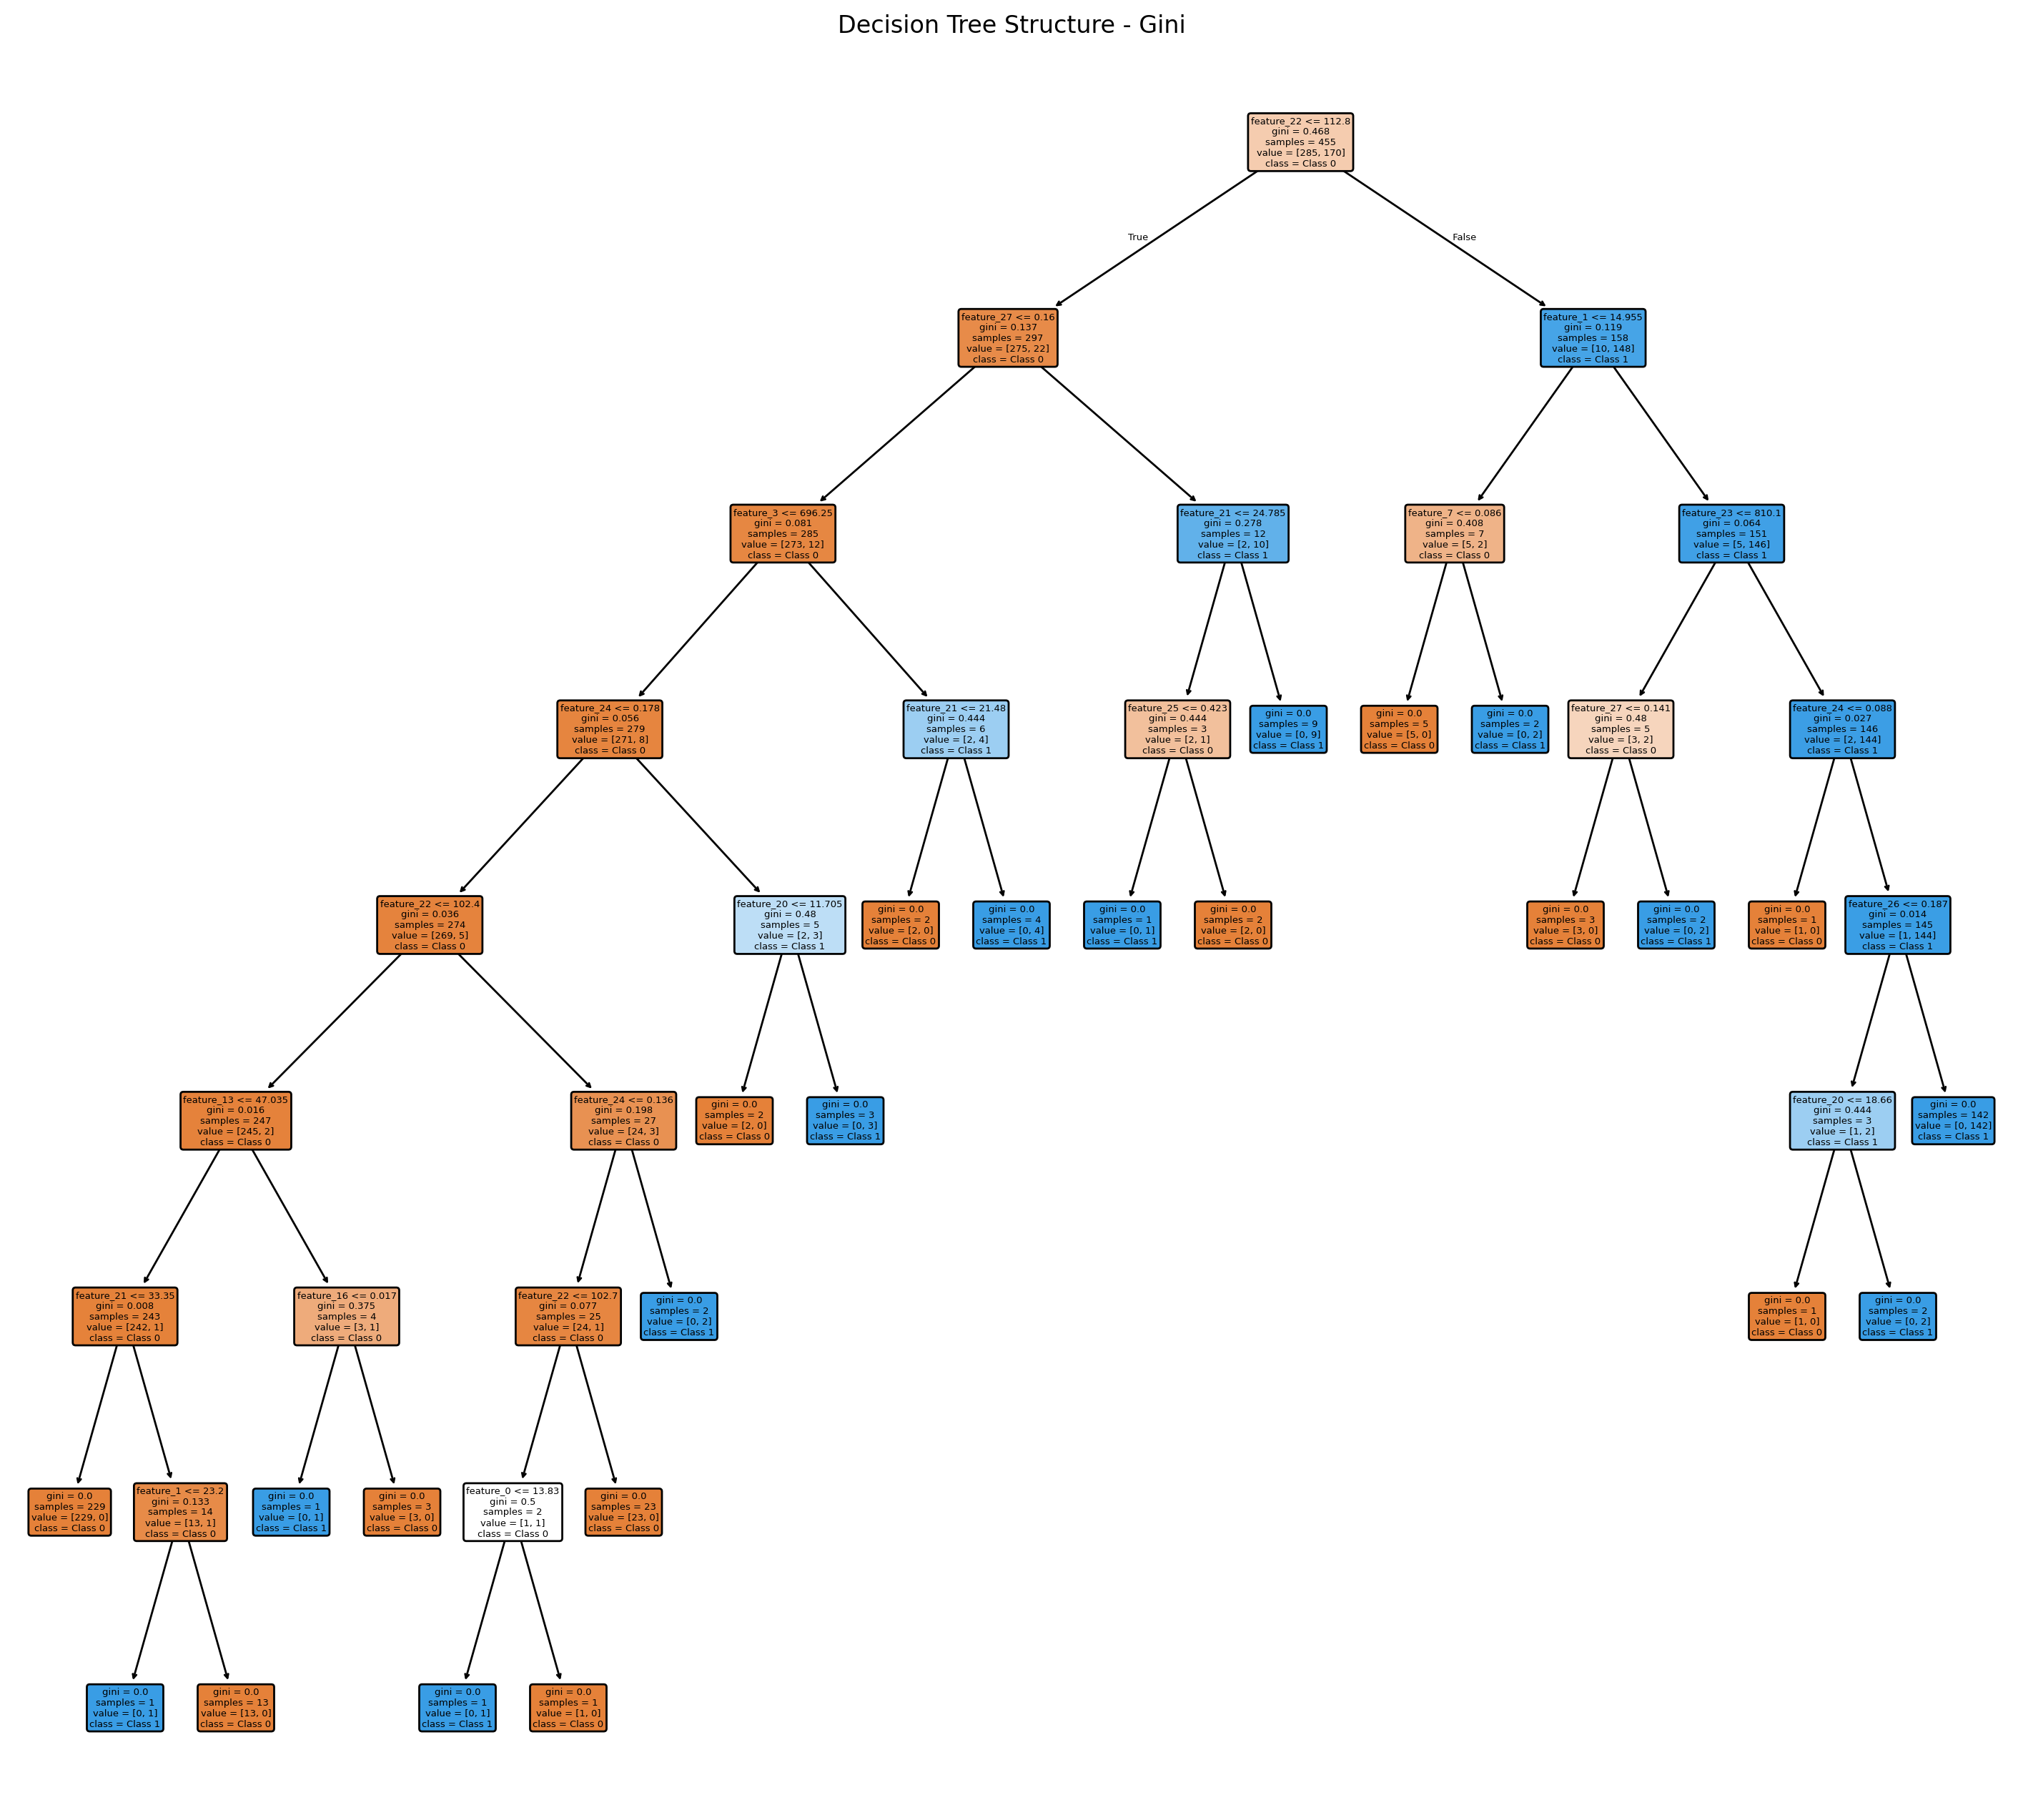

In [17]:
from sklearn.tree import plot_tree

# Plot the decision tree
fig, ax = plt.subplots(figsize=(18, 16), dpi=200)
plot_tree(
	dtc_1,
	feature_names=[f"feature_{i}" for i in range(X.shape[1])],
	class_names=["Class 0", "Class 1"],
	filled=True,
	rounded=True,
	ax=ax,
)
ax.set_title("Decision Tree Structure - Gini")
plt.show()

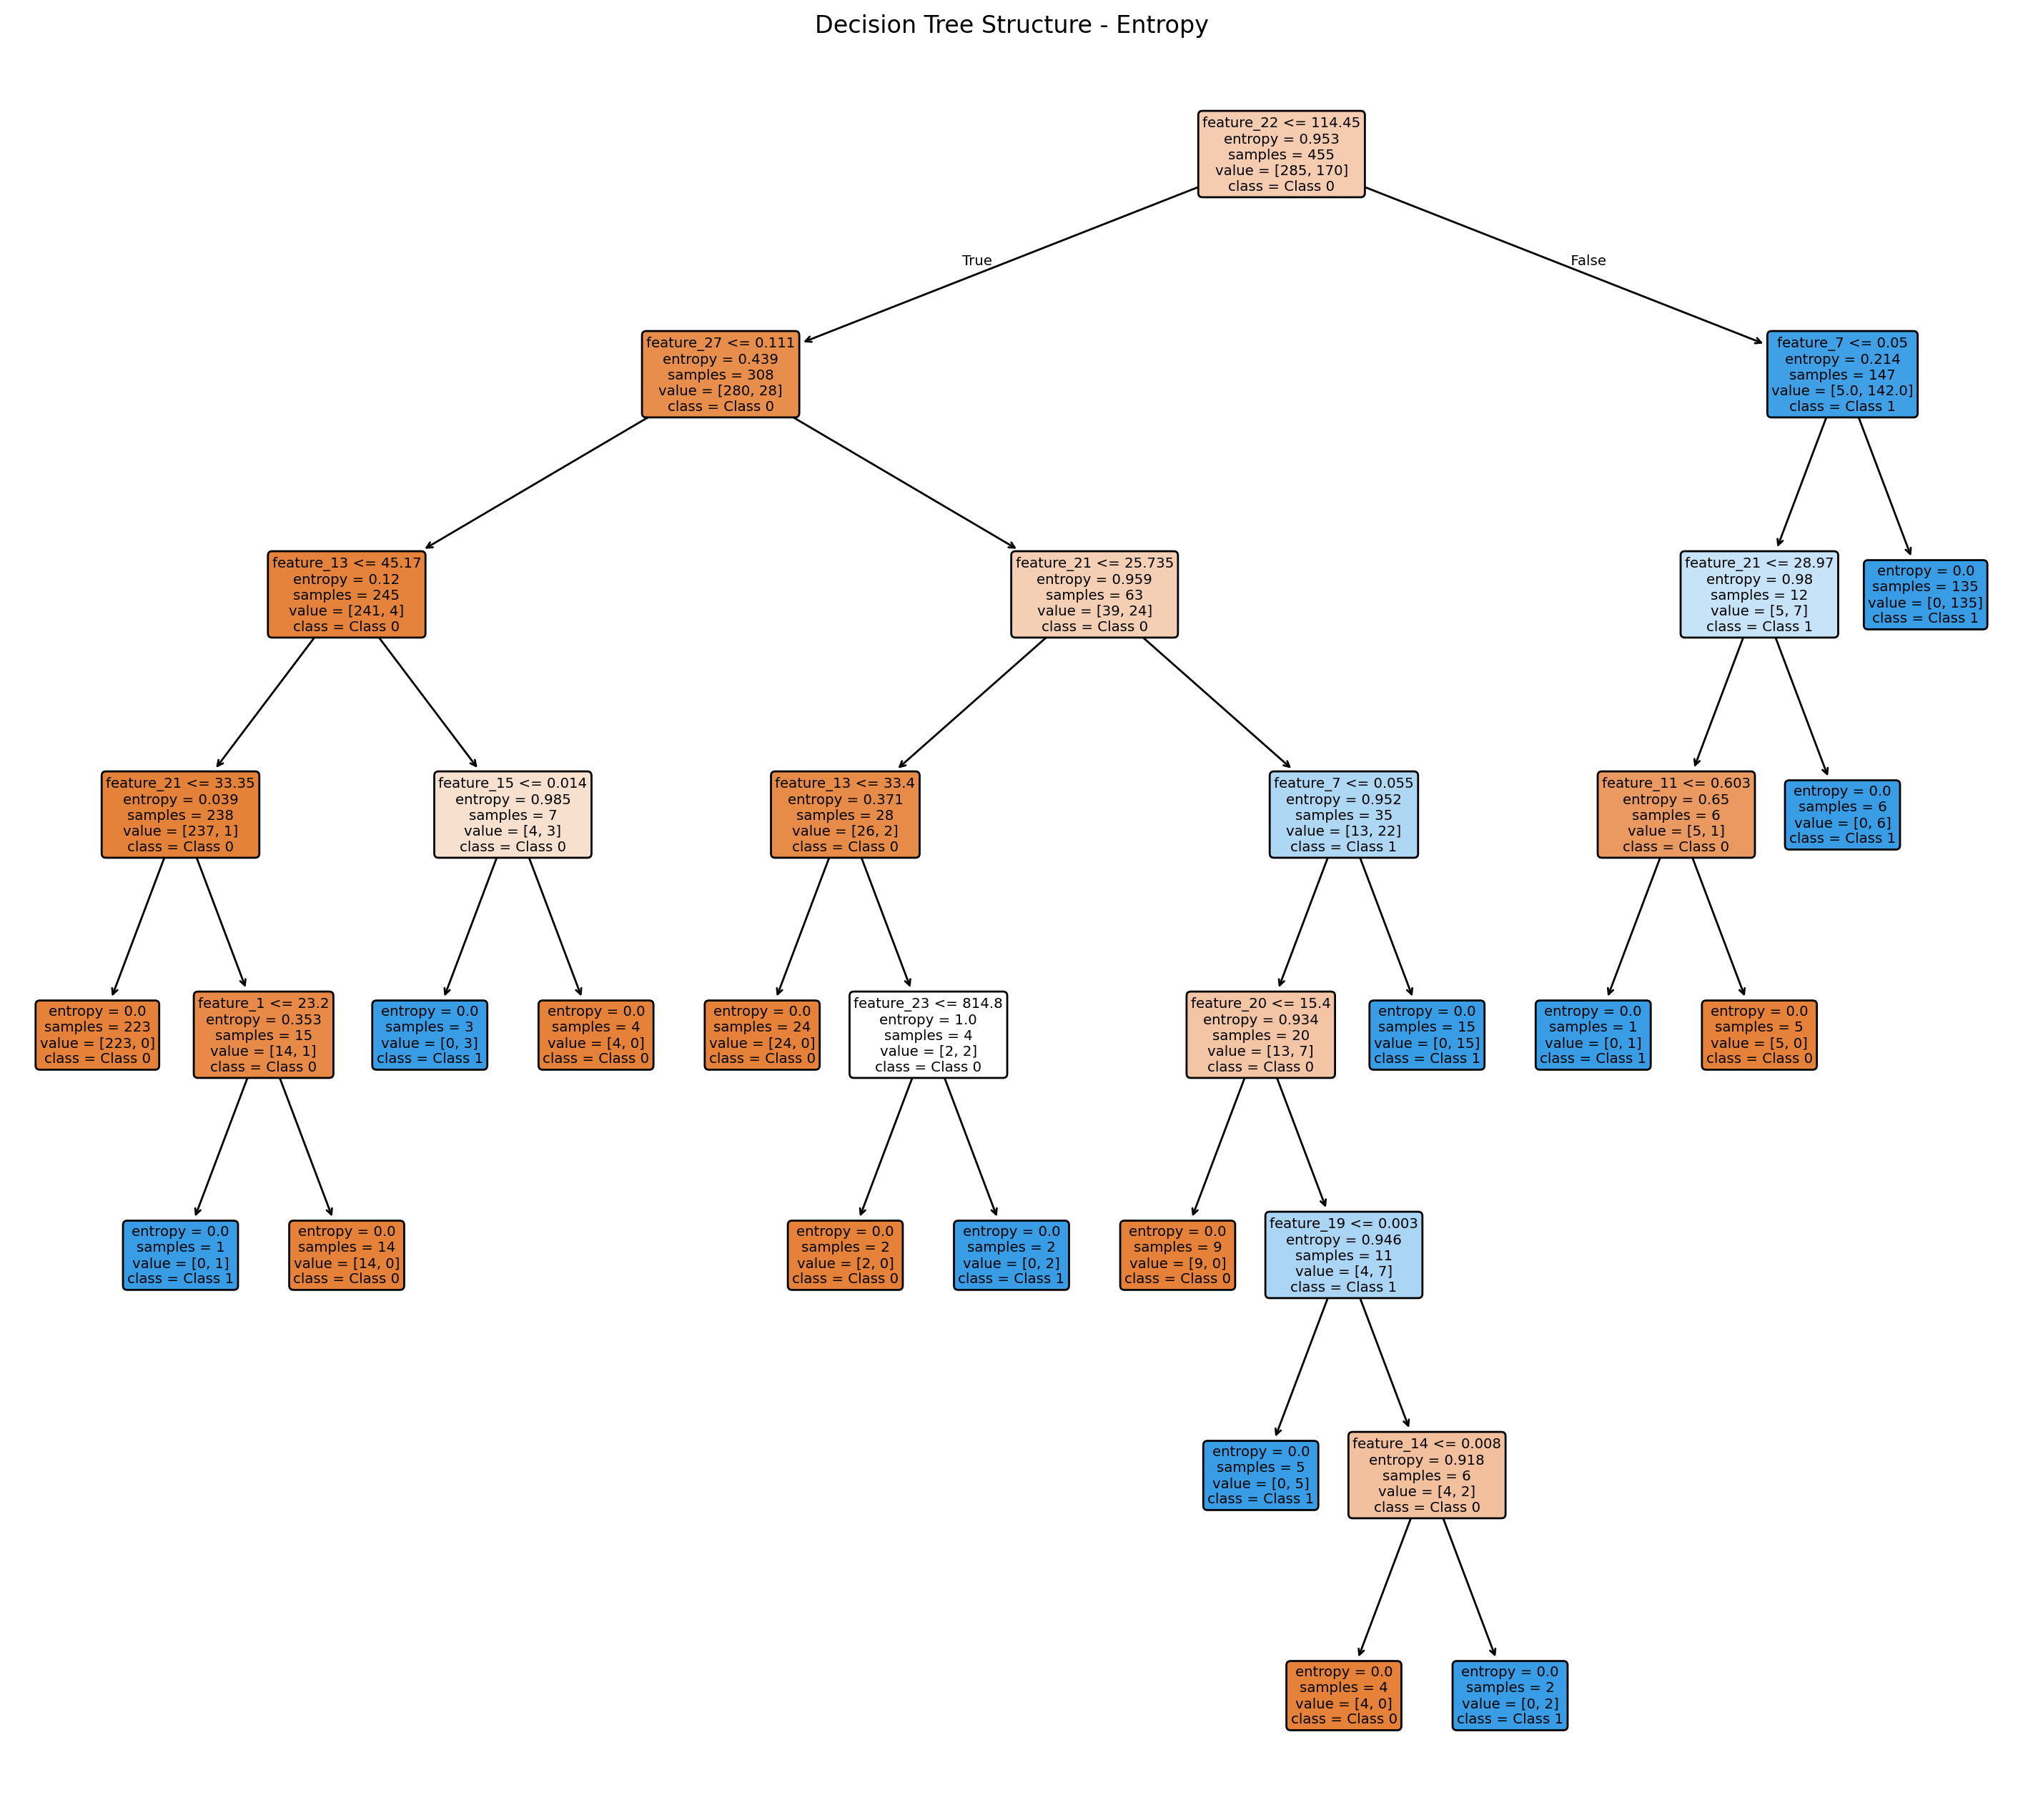

In [18]:
from sklearn.tree import plot_tree

# Plot the decision tree
fig, ax = plt.subplots(figsize=(18, 16), dpi=200)
plot_tree(
	dtc_2,
	feature_names=[f"feature_{i}" for i in range(X.shape[1])],
	class_names=["Class 0", "Class 1"],
	filled=True,
	rounded=True,
	ax=ax,
)
ax.set_title("Decision Tree Structure - Entropy")
plt.show()


### Evaluation

Your exercise is complete when:

* Both trees are trained and evaluated without error.
* You print both accuracies clearly (e.g., `Accuracy (Gini) = 0.96`, `Accuracy (Entropy) = 0.95`).
* You provide a concise explanation of why they differ (or don’t).

### Model Comparison: Gini vs Entropy

Performance Results:
- Gini Accuracy: 0.9561 (95.6%)
- Entropy Accuracy: 0.9474 (94.7%)

Key Differences:

1. Tree Complexity:
	- Gini tree: 19 leaves
	- Entropy tree: 21 leaves
	- Entropy produces a slightly more complex tree structure

2. Splitting Behavior:
	- Gini Impurity focuses on minimizing classification error probability
	- Entropy maximizes information gain by reducing uncertainty
	- Both criteria lead to similar root splits but diverge in deeper nodes

3. Practical Impact:
	- Minimal performance difference (0.9% accuracy gap)
	- Gini is computationally faster (no logarithmic calculations)
	- Entropy may capture more nuanced patterns but risks overfitting

4. Classification Performance:
	- Both models achieve high precision and recall for both classes
	- Gini shows slightly better F1-scores across both malignant and benign classes
	- Both models maintain balanced performance, indicating no significant class bias

Conclusion: For this medical dataset, both criteria perform nearly identically. The Gini criterion offers slightly better accuracy with a simpler tree structure, making it preferable for clinical applications where interpretability and computational efficiency matter. The minimal performance difference suggests that either criterion would be suitable for this classification task, with the choice potentially depending on specific requirements for model complexity versus computational resources.

### Stretch Ideas

* Plot validation curves showing accuracy vs. `max_depth` for both criteria.
* Use cross-validation to test stability of results.
* Compute other metrics (precision, recall, F1-score) to evaluate robustness.
